# EDA: Bike Sharing

In [1]:
import sys
import os
sys.path.append(os.path.join(os.getcwd(), "../.."))


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from ucimlrepo import fetch_ucirepo

from src.preprocess import add_cyclic_hour


## Load Dataset

In [ ]:
bike_sharing = fetch_ucirepo(id=275)

X = bike_sharing.data.features.copy()
y = bike_sharing.data.targets.copy()

print(f'Features : {X.shape}')
print(f'Targets  : {y.shape}')


Features : (17379, 13)
Targets  : (17379, 1)


## Initial Exploration

In [4]:
X.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0


In [5]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      17379 non-null  str    
 1   season      17379 non-null  int64  
 2   yr          17379 non-null  int64  
 3   mnth        17379 non-null  int64  
 4   hr          17379 non-null  int64  
 5   holiday     17379 non-null  int64  
 6   weekday     17379 non-null  int64  
 7   workingday  17379 non-null  int64  
 8   weathersit  17379 non-null  int64  
 9   temp        17379 non-null  float64
 10  atemp       17379 non-null  float64
 11  hum         17379 non-null  float64
 12  windspeed   17379 non-null  float64
dtypes: float64(4), int64(8), str(1)
memory usage: 1.9 MB


In [6]:
y.head()

,cnt
0,16
1,40
2,32
3,13
4,1


| Column       | Role     | Type        | Description                                              |
|--------------|----------|-------------|----------------------------------------------------------|
| instant      | ID       | Integer     | Record index                                             |
| dteday       | Feature  | Date        | Date                                                     |
| season       | Feature  | Categorical | 1=Winter, 2=Spring, 3=Summer, 4=Fall                     |
| yr           | Feature  | Categorical | 0=2011, 1=2012                                           |
| mnth         | Feature  | Categorical | Month (1–12)                                             |
| hr           | Feature  | Categorical | Hour (0–23)                                              |
| holiday      | Feature  | Binary      | Whether the day is a holiday                             |
| weekday      | Feature  | Categorical | Day of the week                                          |
| workingday   | Feature  | Binary      | 1 if neither weekend nor holiday                         |
| weathersit   | Feature  | Categorical | 1=Clear … 4=Heavy Rain                                   |
| temp         | Feature  | Continuous  | Normalised temperature in Celsius (−8 to 39)             |
| atemp        | Feature  | Continuous  | Normalised feeling temperature (−16 to 50)               |
| hum          | Feature  | Continuous  | Normalised humidity ÷ 100                                |
| windspeed    | Feature  | Continuous  | Normalised wind speed ÷ 67                               |
| casual       | Other    | Integer     | Count of casual users                                    |
| registered   | Other    | Integer     | Count of registered users                                |
| cnt          | Target   | Integer     | Total rentals (casual + registered)                      |


### Missing Values

In [7]:
missing = X.isna().sum()
print(missing[missing > 0] if missing.any() else 'No missing values in features.')
print()
print('Target missing:', y.isna().sum().item())


No missing values in features.

Target missing: 0


## Univariate Analysis

### Numerical Features

── temp ──


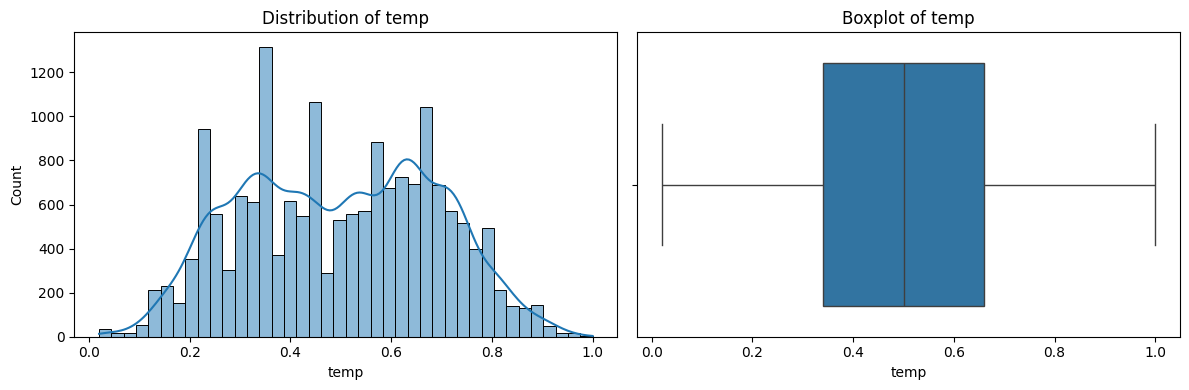

count    17379.000000
mean         0.496987
std          0.192556
min          0.020000
25%          0.340000
50%          0.500000
75%          0.660000
max          1.000000
Name: temp, dtype: float64

── atemp ──


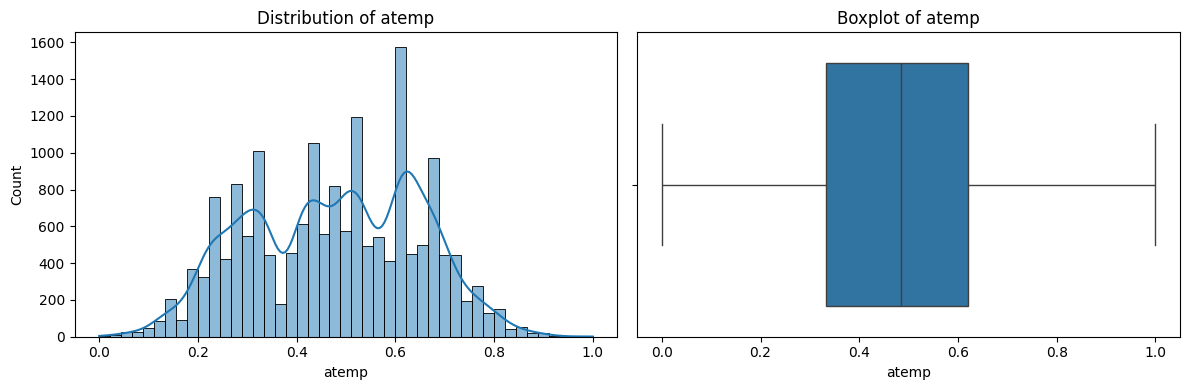

count    17379.000000
mean         0.475775
std          0.171850
min          0.000000
25%          0.333300
50%          0.484800
75%          0.621200
max          1.000000
Name: atemp, dtype: float64

── hum ──


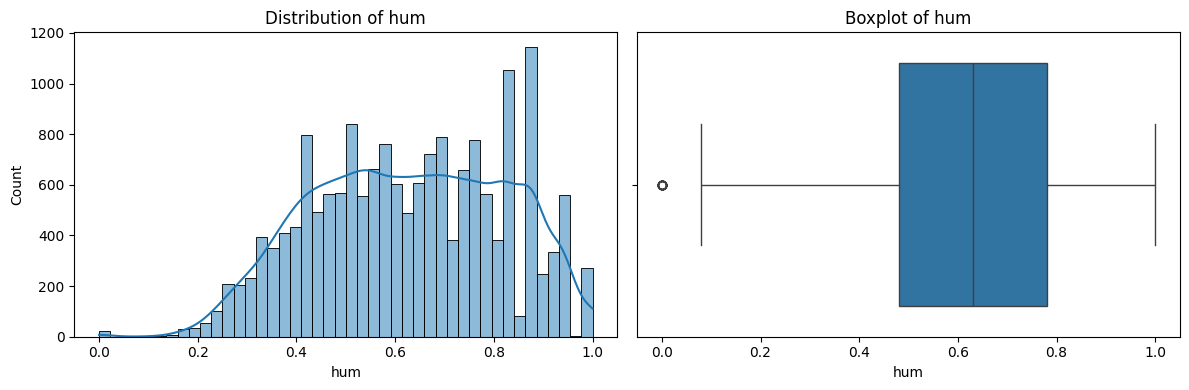

count    17379.000000
mean         0.627229
std          0.192930
min          0.000000
25%          0.480000
50%          0.630000
75%          0.780000
max          1.000000
Name: hum, dtype: float64

── windspeed ──


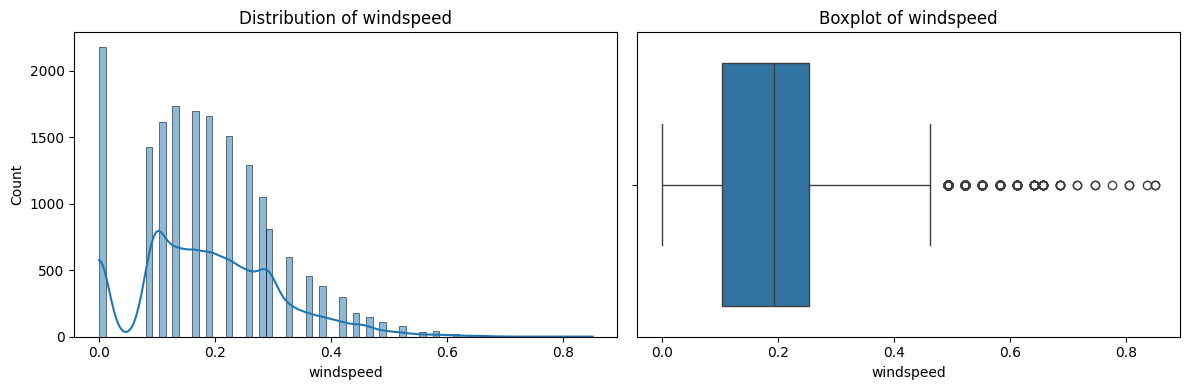

count    17379.000000
mean         0.190098
std          0.122340
min          0.000000
25%          0.104500
50%          0.194000
75%          0.253700
max          0.850700
Name: windspeed, dtype: float64



In [8]:
num_features = ['temp', 'atemp', 'hum', 'windspeed']

def univariate_num(df, feature):
    summary = df[feature].describe()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(data=df, x=feature, kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {feature}')
    sns.boxplot(x=df[feature], ax=axes[1])
    axes[1].set_title(f'Boxplot of {feature}')
    plt.tight_layout()
    plt.show()
    return summary

for feat in num_features:
    print(f'── {feat} ──')
    print(univariate_num(X, feat))
    print()


#### Target: `cnt`

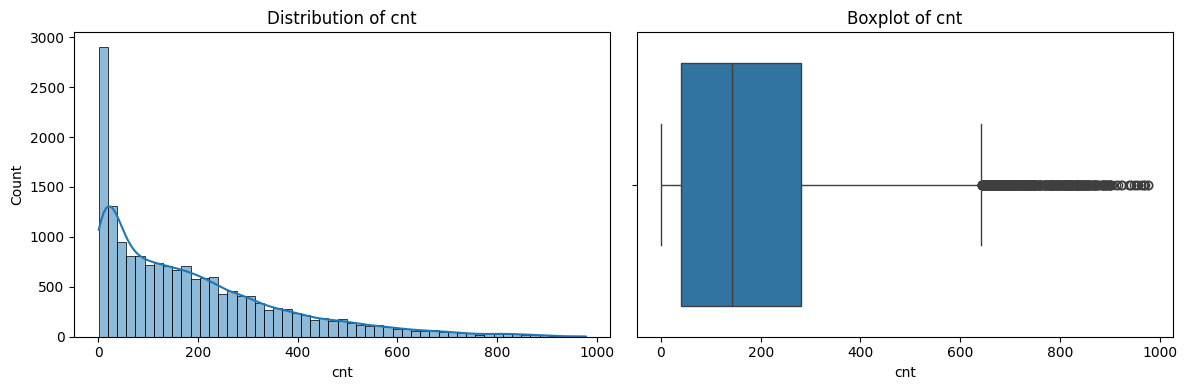

count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64

In [9]:
univariate_num(y, 'cnt')

### Categorical Features

── season ──


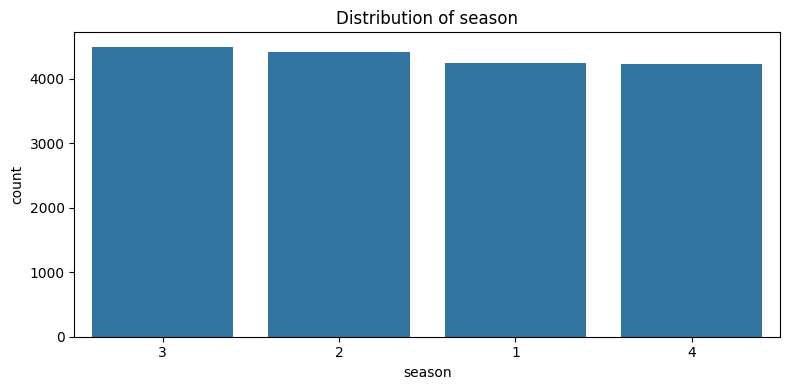

        Count  Percentage (%)
season                       
3        4496       25.870303
2        4409       25.369699
1        4242       24.408769
4        4232       24.351228

── yr ──


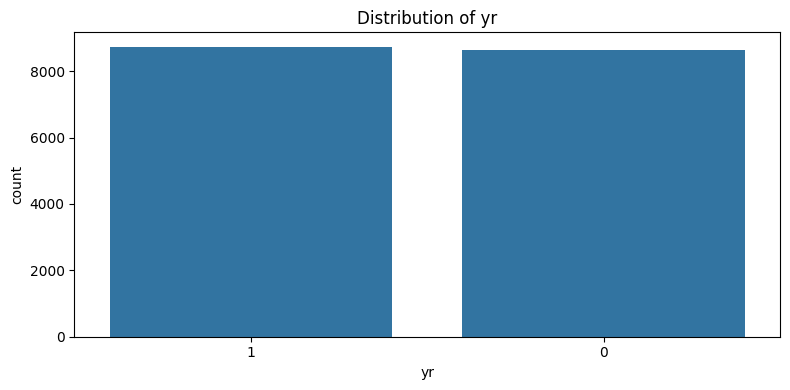

    Count  Percentage (%)
yr                       
1    8734       50.256056
0    8645       49.743944

── mnth ──


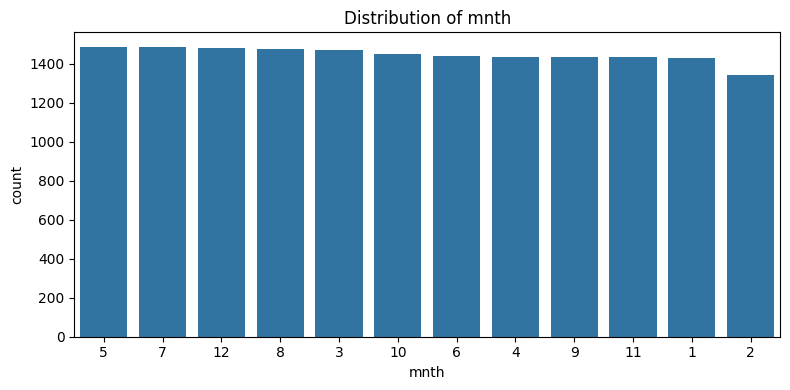

      Count  Percentage (%)
mnth                       
5      1488        8.562058
7      1488        8.562058
12     1483        8.533287
8      1475        8.487255
3      1473        8.475747
10     1451        8.349157
6      1440        8.285862
4      1437        8.268600
9      1437        8.268600
11     1437        8.268600
1      1429        8.222567
2      1341        7.716209

── hr ──


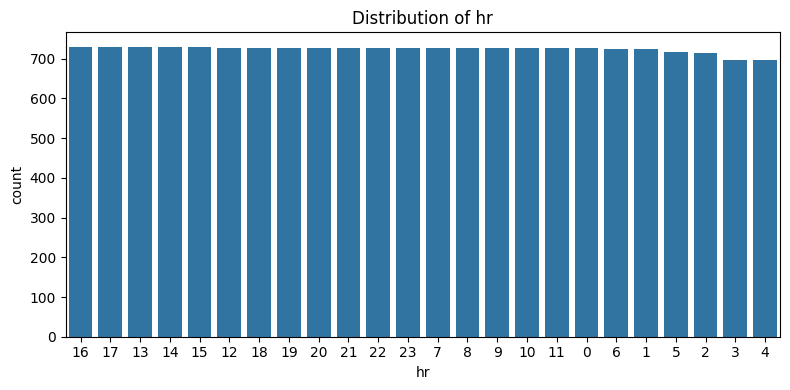

    Count  Percentage (%)
hr                       
16    730        4.200472
17    730        4.200472
13    729        4.194718
14    729        4.194718
15    729        4.194718
12    728        4.188964
18    728        4.188964
19    728        4.188964
20    728        4.188964
21    728        4.188964
22    728        4.188964
23    728        4.188964
7     727        4.183210
8     727        4.183210
9     727        4.183210
10    727        4.183210
11    727        4.183210
0     726        4.177456
6     725        4.171701
1     724        4.165947
5     717        4.125669
2     715        4.114161
3     697        4.010587
4     697        4.010587

── holiday ──


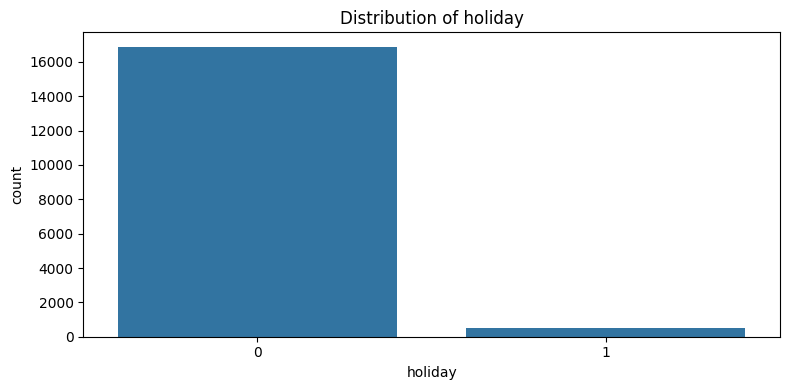

         Count  Percentage (%)
holiday                       
0        16879       97.122964
1          500        2.877036

── weekday ──


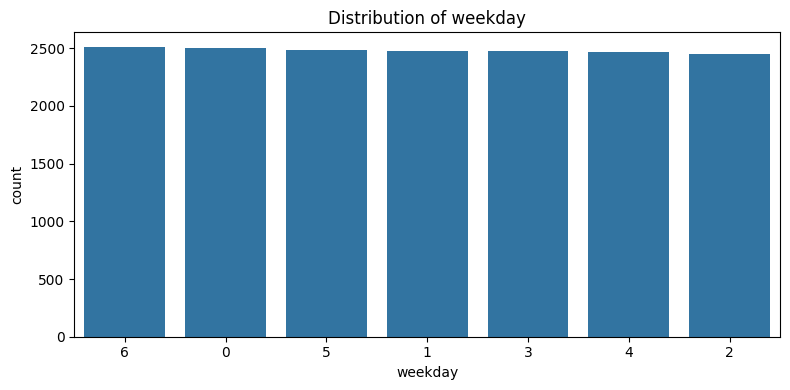

         Count  Percentage (%)
weekday                       
6         2512       14.454226
0         2502       14.396686
5         2487       14.310375
1         2479       14.264342
3         2475       14.241326
4         2471       14.218309
2         2453       14.114736

── workingday ──


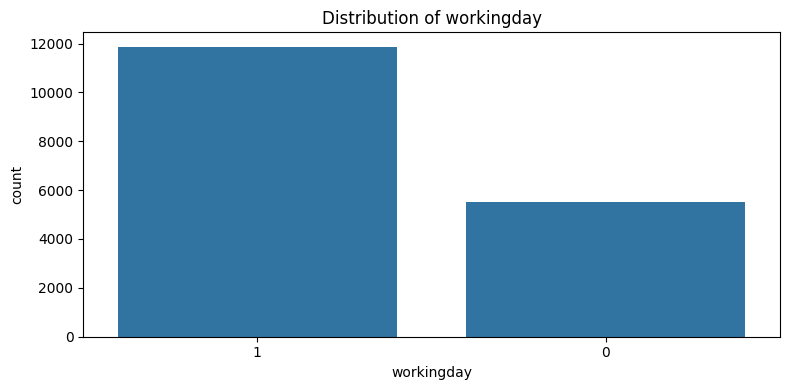

            Count  Percentage (%)
workingday                       
1           11865       68.272052
0            5514       31.727948

── weathersit ──


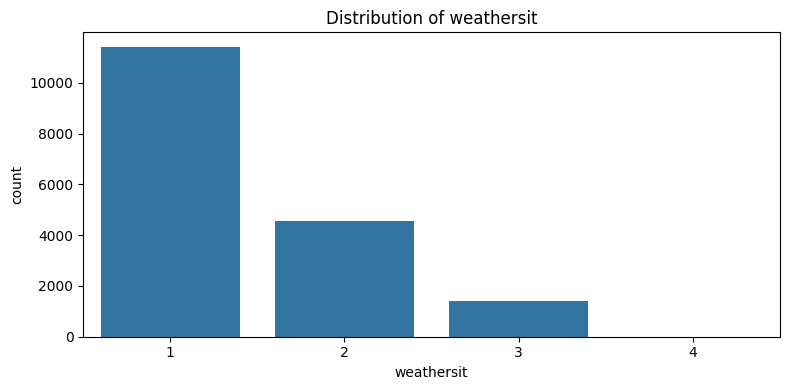

            Count  Percentage (%)
weathersit                       
1           11413       65.671212
2            4544       26.146499
3            1419        8.165027
4               3        0.017262



In [10]:
cat_features = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']

def univariate_cat(df, feature):
    counts      = df[feature].value_counts()
    percentages = df[feature].value_counts(normalize=True) * 100
    summary     = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages})
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=feature, order=counts.index)
    plt.title(f'Distribution of {feature}')
    plt.tight_layout()
    plt.show()
    return summary

for feat in cat_features:
    print(f'── {feat} ──')
    print(univariate_cat(X, feat))
    print()


## Bivariate Analysis

### Numerical Features × Target

── temp ──


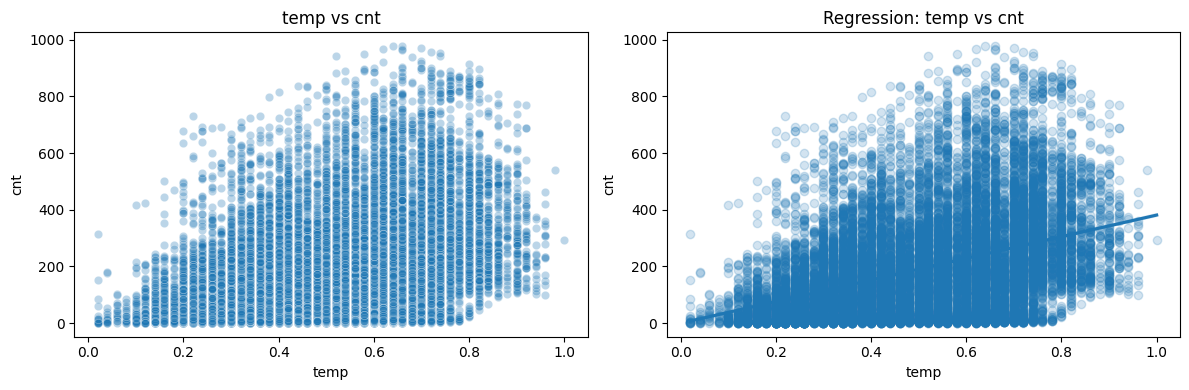

── atemp ──


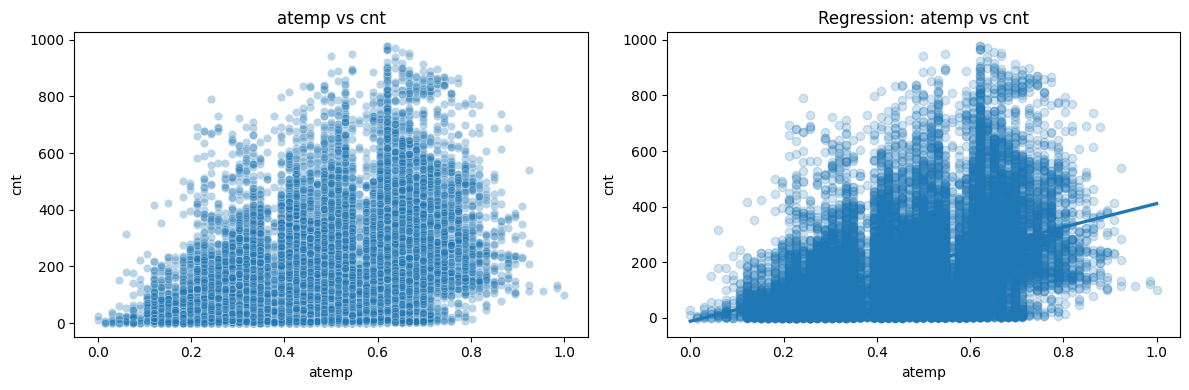

── hum ──


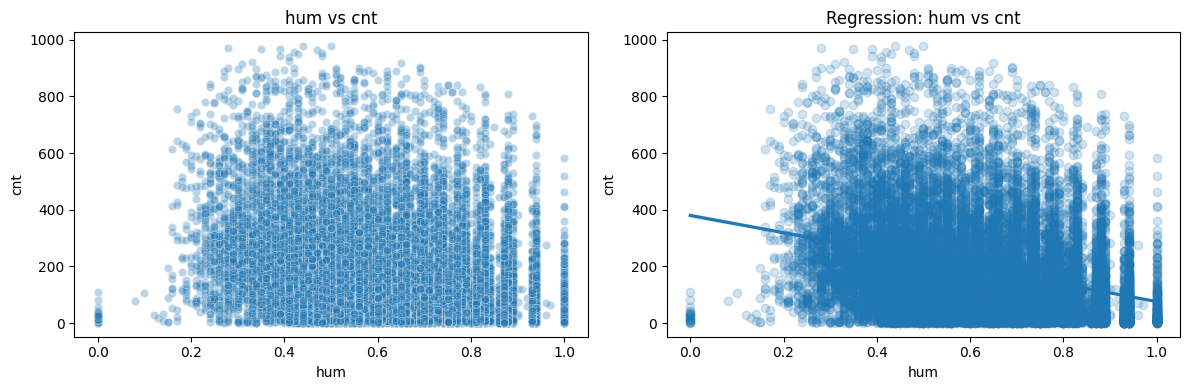

── windspeed ──


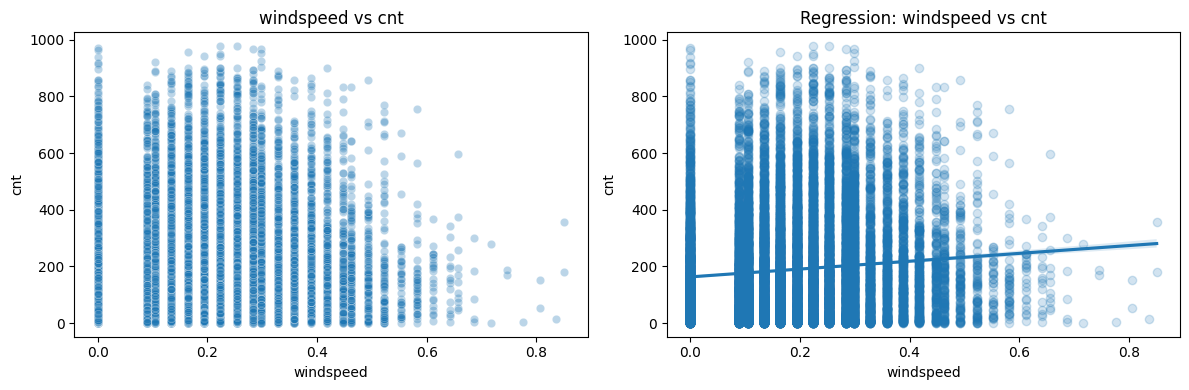

In [11]:
def bivariate_num(X, y, feature):
    data = pd.concat([X[[feature]], y], axis=1)
    data.columns = [feature, 'cnt']
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.scatterplot(data=data, x=feature, y='cnt', alpha=0.3, ax=axes[0])
    axes[0].set_title(f'{feature} vs cnt')
    sns.regplot(data=data, x=feature, y='cnt', scatter_kws={'alpha': 0.2}, ax=axes[1])
    axes[1].set_title(f'Regression: {feature} vs cnt')
    plt.tight_layout()
    plt.show()

for feat in num_features:
    print(f'── {feat} ──')
    bivariate_num(X, y, feat)


### Categorical Features × Target

── season ──


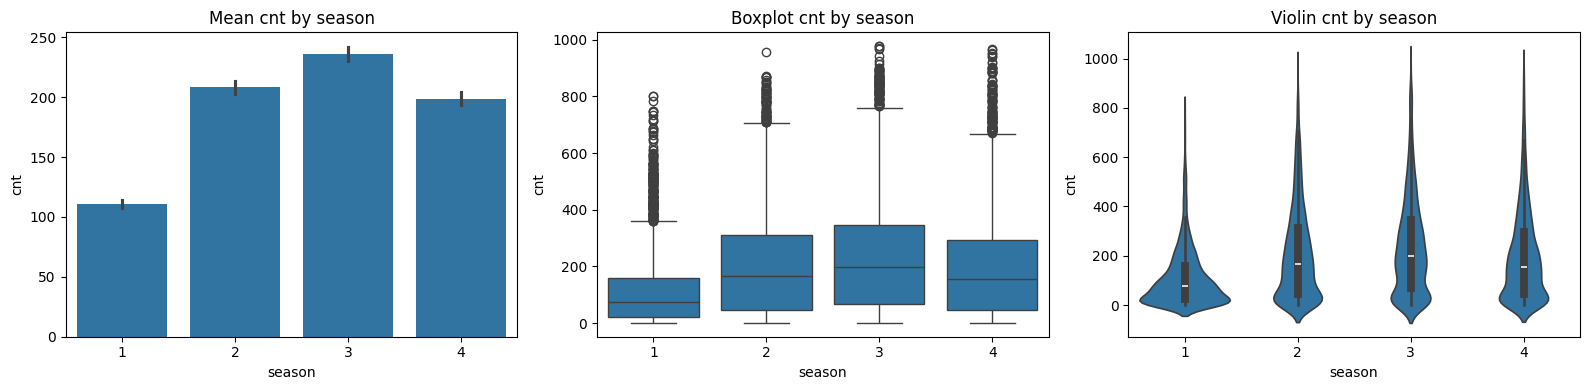

── yr ──


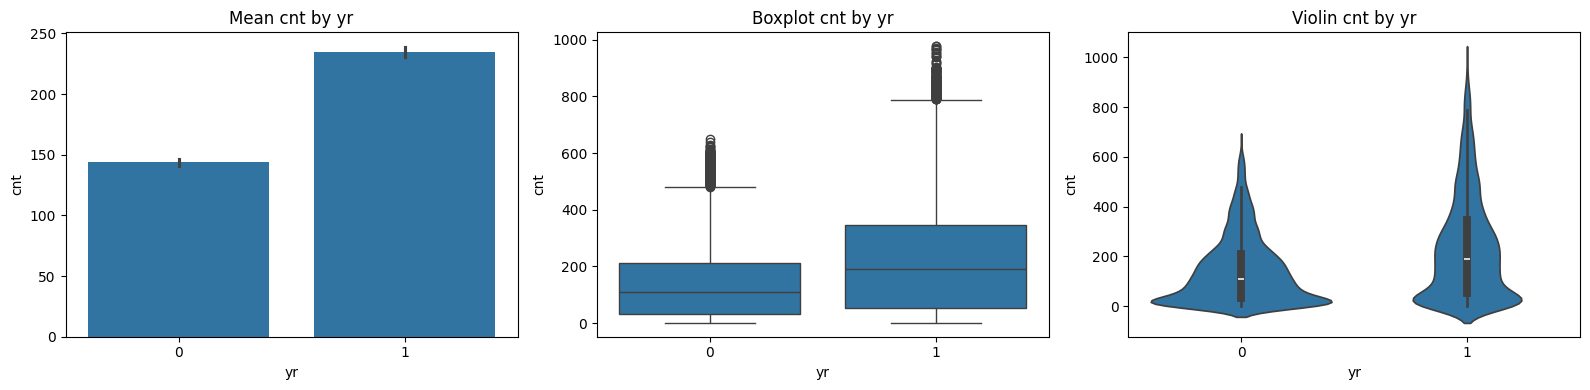

── mnth ──


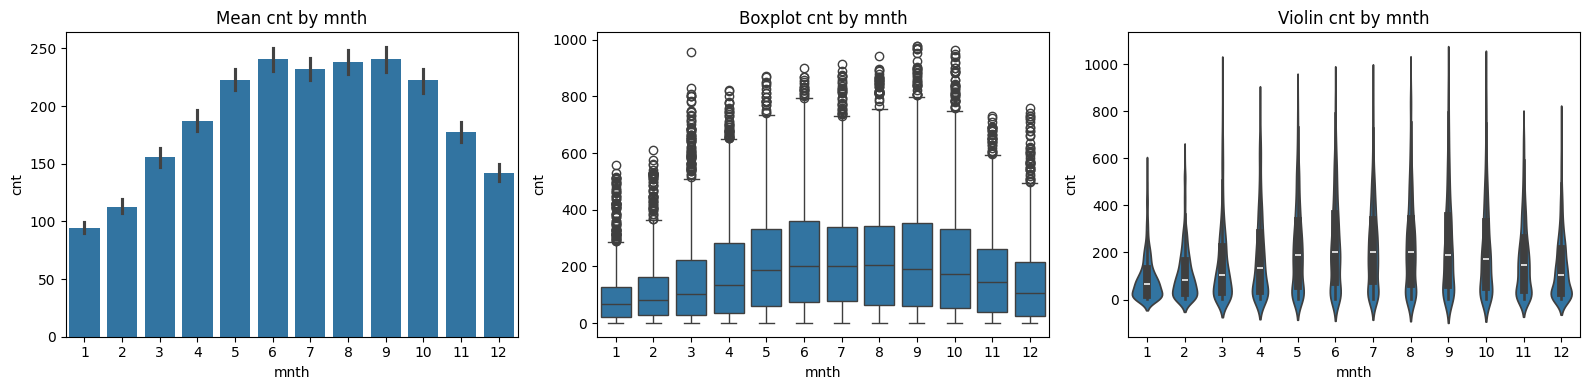

── hr ──


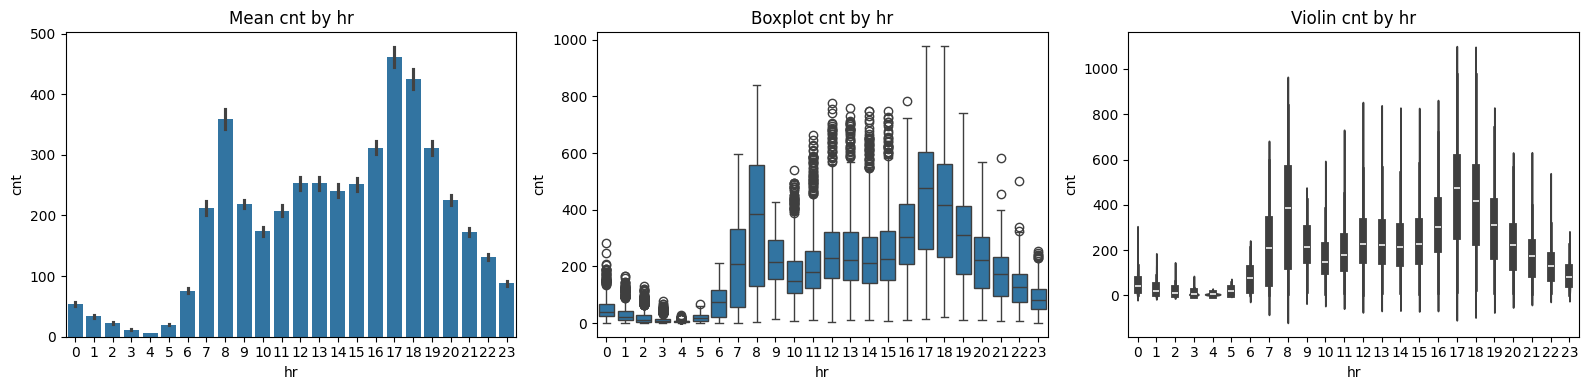

── holiday ──


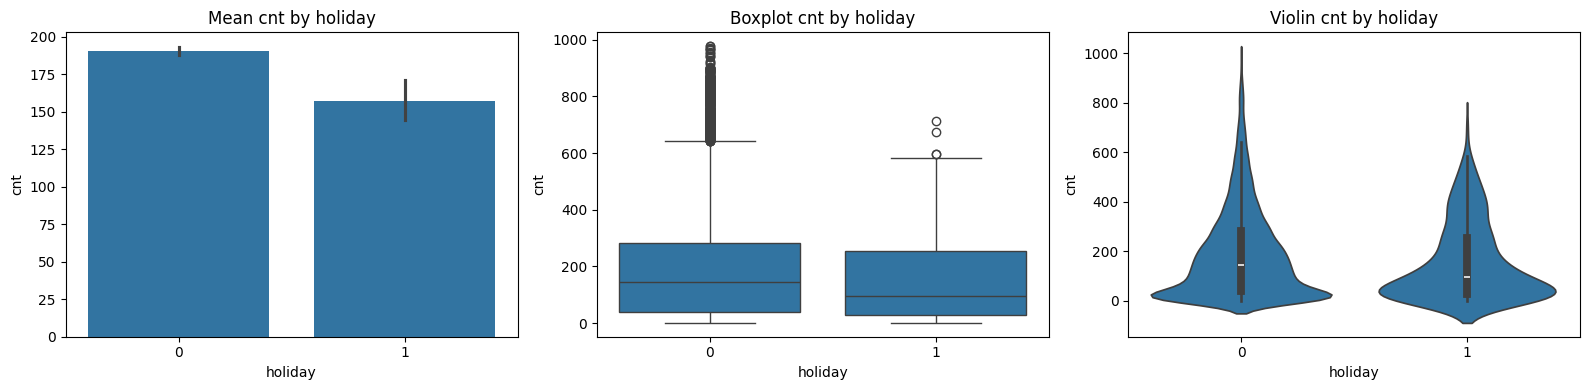

── weekday ──


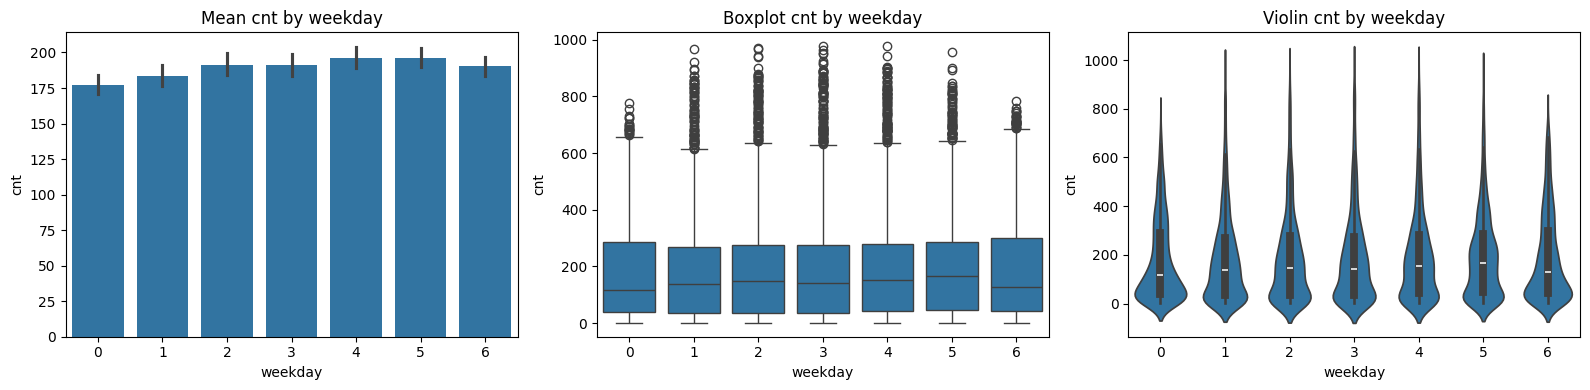

── workingday ──


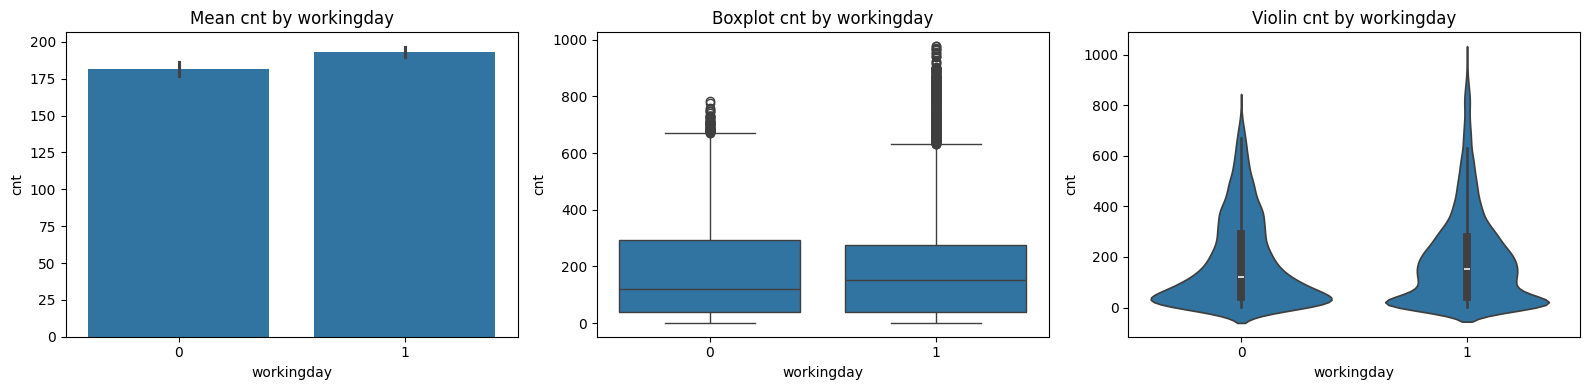

── weathersit ──


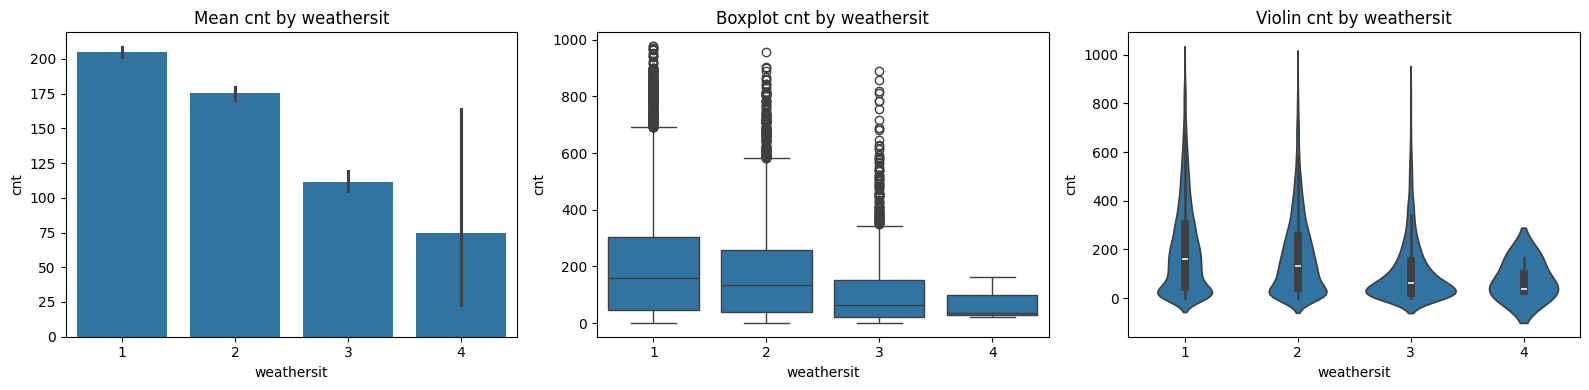

In [12]:
def bivariate_cat(X, y, feature):
    data = pd.concat([X[[feature]], y], axis=1)
    data.columns = [feature, 'cnt']
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    sns.barplot(data=data, x=feature, y='cnt', ax=axes[0])
    axes[0].set_title(f'Mean cnt by {feature}')
    sns.boxplot(data=data, x=feature, y='cnt', ax=axes[1])
    axes[1].set_title(f'Boxplot cnt by {feature}')
    sns.violinplot(data=data, x=feature, y='cnt', ax=axes[2])
    axes[2].set_title(f'Violin cnt by {feature}')
    plt.tight_layout()
    plt.show()

for feat in cat_features:
    print(f'── {feat} ──')
    bivariate_cat(X, y, feat)


### Pairplot (Numerical Features + Target)

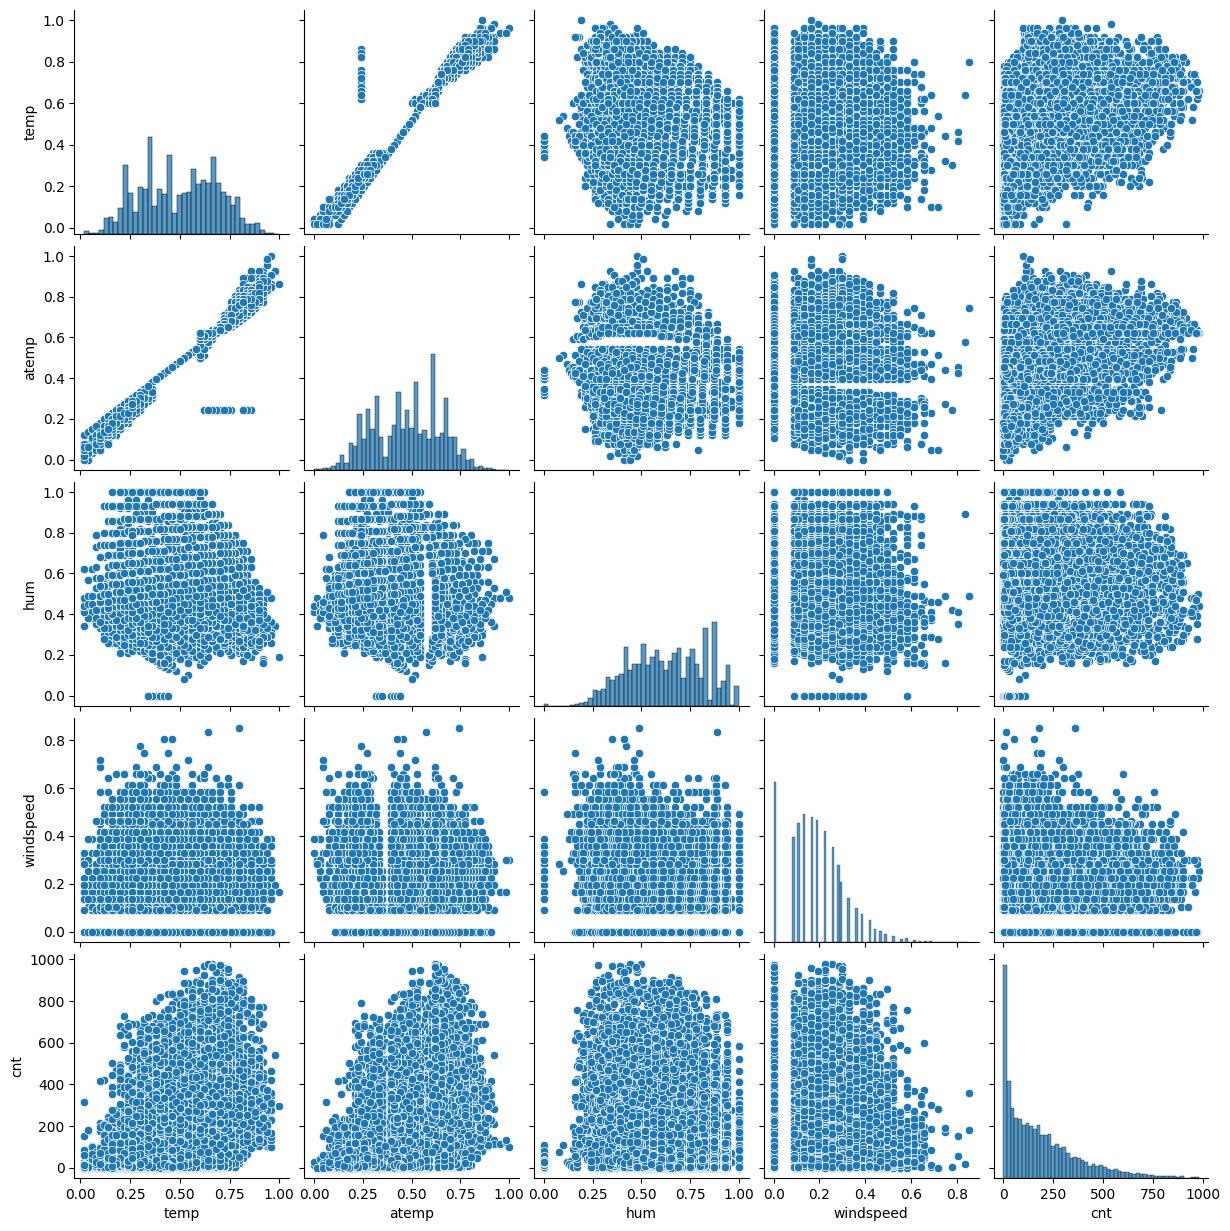

In [13]:
sns.pairplot(pd.concat([X[num_features], y], axis=1))
plt.show()


### Correlation Heatmap

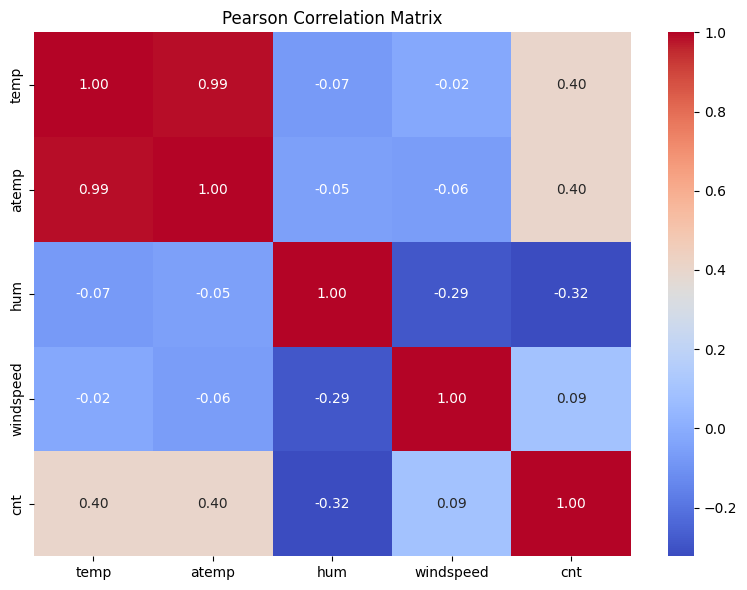

In [14]:
corr = pd.concat([X[num_features], y], axis=1).corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()


**Observations:**
- `temp` and `atemp` are almost perfectly linearly correlated (r ≈ 0.99). Since `atemp` has higher mutual information with the target, we will **drop `temp`**.
- `hum` and `windspeed` have a slight negative relationship with `cnt`.


## Preprocessing

### Outlier / Rare Category: `weathersit == 4`

In [15]:
print('weathersit value counts:')
print(X['weathersit'].value_counts())
print()
# Only 3 records with weathersit=4 (Heavy Rain/Ice) — remove them
mask = X['weathersit'] != 4
X, y = X[mask].reset_index(drop=True), y[mask].reset_index(drop=True)
print(f'Dataset after removing weathersit=4: {X.shape}')


weathersit value counts:
weathersit
1    11413
2     4544
3     1419
4        3
Name: count, dtype: int64

Dataset after removing weathersit=4: (17376, 13)


### Feature Selection via Mutual Information

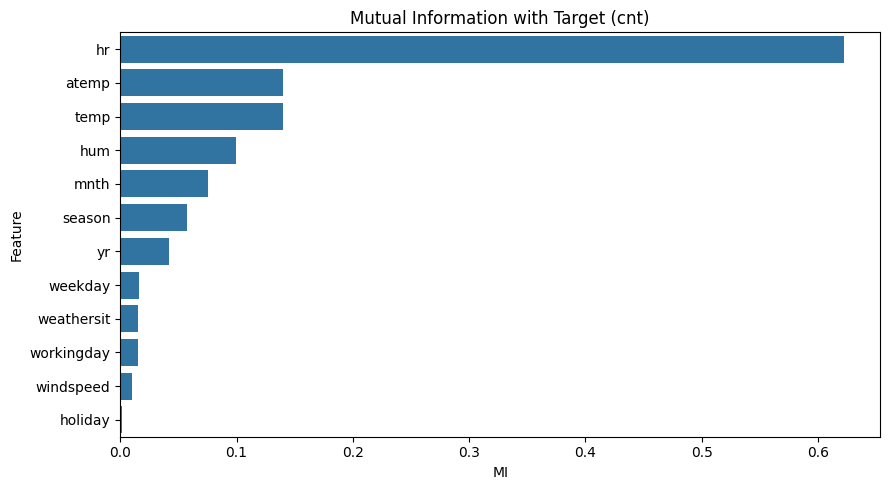

,Feature,MI
3,hr,0.622316
9,atemp,0.140244
8,temp,0.139818
10,hum,0.099566
2,mnth,0.075517
0,season,0.057313
1,yr,0.041957
5,weekday,0.015973
7,weathersit,0.015169
6,workingday,0.014821


In [16]:
from sklearn.feature_selection import mutual_info_regression

X_mi          = X.drop(columns=['dteday']).copy()
discrete_mask = X_mi.columns.isin(cat_features)

mi    = mutual_info_regression(X_mi, y.values.ravel(), discrete_features=discrete_mask, random_state=42)
mi_df = pd.DataFrame({'Feature': X_mi.columns, 'MI': mi}).sort_values('MI', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=mi_df, x='MI', y='Feature')
plt.title('Mutual Information with Target (cnt)')
plt.tight_layout()
plt.show()

mi_df


### Feature Engineering Decisions

| Decision | Reason |
|---|---|
| Drop `instant`, `dteday` | ID / date string — no predictive value after other time features are included |
| Drop `casual`, `registered` | Data leakage: they sum to `cnt` |
| Drop `temp` | Perfectly collinear with `atemp` (r = 0.99); `atemp` is more informative |
| Drop `holiday`, `weekday` | Low MI; `workingday` already captures the working/non-working distinction |
| Drop `mnth` | Redundant with `season`; much higher cardinality for marginal gain |
| Cyclical encode `hr` | Hours are periodic — sin/cos avoids a false ordinal gap between 23 and 0 |
| One-hot encode `season`, `weathersit` | Nominal categoricals with no natural order |


### Correlation between `mnth` and `season`

In [17]:
tab = pd.crosstab(X['mnth'], X['season'])
chi2, p, dof, _ = chi2_contingency(tab)
n = tab.sum().sum()
cramers_v = np.sqrt((chi2 / n) / (min(tab.shape) - 1))
print(f"Cramér's V (mnth × season): {cramers_v:.3f}  (p={p:.2e})")
print('=> Strong association — drop mnth, keep season.')


Cramér's V (mnth × season): 0.896  (p=0.00e+00)
=> Strong association — drop mnth, keep season.


### Final Feature Set Preview

`add_cyclic_hour` from `src.preprocess` takes a column (array-like) and returns `(sin_hour, cos_hour)`. Below we apply it to preview the final feature set without modifying the working copies of `X` and `y`.


In [18]:
# Preview only — does not modify X / y used above
X_preview = X.drop(columns=['dteday', 'temp', 'holiday', 'weekday', 'mnth']).copy()

X_preview['hr_sin'], X_preview['hr_cos'] = add_cyclic_hour(X_preview['hr'])
X_preview.drop(columns=['hr'], inplace=True)

X_preview = pd.get_dummies(X_preview, columns=['season', 'weathersit'], drop_first=True)
bool_cols = X_preview.select_dtypes('bool').columns
X_preview[bool_cols] = X_preview[bool_cols].astype(int)

print(f'Final feature count: {X_preview.shape[1]}')
print(X_preview.dtypes)


Final feature count: 12
yr                int64
workingday        int64
atemp           float64
hum             float64
windspeed       float64
hr_sin          float64
hr_cos          float64
season_2          int64
season_3          int64
season_4          int64
weathersit_2      int64
weathersit_3      int64
dtype: object
